# 01 — Data Exploration

Fetch OHLCV data for all tracked assets from Binance, compute technical indicators, and save to parquet.

In [23]:
# ── Asset configuration ───────────────────────────────────────────────────────
# Edit this dict to add/remove symbols. All downstream cells derive from it.
COIN_IDS = {
    "BTCUSDT":  "bitcoin",
    "ETHUSDT":  "ethereum",
    "BNBUSDT":  "binancecoin",
    "XRPUSDT":  "ripple",
    "SOLUSDT":  "solana",
    "ADAUSDT":  "cardano",
    "DOGEUSDT": "dogecoin",
    "AVAXUSDT": "avalanche-2",
    "DOTUSDT":  "polkadot",
    "LINKUSDT": "chainlink",
}

INTERVAL = '1h'


In [24]:
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import requests

from hmats.data.binance_store import fetch_and_store, load
from hmats.data.pipeline import compute_indicators

warnings.filterwarnings('ignore', category=FutureWarning)
pd.options.display.max_columns = 30

# ── Research-grade plot style ─────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.framealpha": 0.85,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

ACCENT   = '#F7931A'  # Bitcoin orange
BLUE     = '#2962FF'
GREY     = '#9E9E9E'
DARKGREY = '#424242'

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()

RAW_DIR = REPO_ROOT / 'data' / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = REPO_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## 1. Market cap & earliest candle availability

Fetches CoinGecko ATH data and Binance earliest candle dates for each symbol.
If `crypto_market_caps.csv` already exists the API calls are skipped entirely.

In [25]:
MARKET_CAPS_PATH = RAW_DIR / 'crypto_market_caps.csv'

def _earliest_candle(symbol: str) -> str | None:
    r = requests.get(
        'https://api.binance.com/api/v3/klines',
        params={'symbol': symbol, 'interval': '1h', 'startTime': 0, 'limit': 1},
        timeout=10,
    )
    if r.status_code != 200:
        return None
    data = r.json()
    if not data:
        return None
    dt = datetime.fromtimestamp(data[0][0] / 1000, tz=timezone.utc)
    return dt.strftime('%Y-%m-%d')


def _fetch_coingecko() -> dict[str, dict]:
    r = requests.get(
        'https://api.coingecko.com/api/v3/coins/markets',
        params={
            'vs_currency': 'usd',
            'ids': ','.join(COIN_IDS.values()),
            'order': 'market_cap_desc',
            'per_page': 20,
            'sparkline': 'false',
        },
        timeout=15,
    )
    r.raise_for_status()
    return {c['id']: c for c in r.json()}


if MARKET_CAPS_PATH.exists():
    print(f'crypto_market_caps.csv already exists — loading from {MARKET_CAPS_PATH}')
    caps_df = pd.read_csv(MARKET_CAPS_PATH)
else:
    print('Fetching CoinGecko + Binance availability data...')
    cg = _fetch_coingecko()
    rows = []
    for symbol, coin_id in COIN_IDS.items():
        earliest = _earliest_candle(symbol)
        data = cg.get(coin_id)
        ath = data['ath'] if data else None
        supply = data['circulating_supply'] if data else None
        ath_date = data['ath_date'][:10] if data else None
        peak = ath * supply if ath and supply else None
        rows.append({
            'symbol':              symbol,
            'earliest_1h_candle': earliest,
            'ath_price_usd':      ath,
            'ath_date':           ath_date,
            'circulating_supply': supply,
            'peak_market_cap_usd': peak,
        })
        print(f'  {symbol:<12} earliest={earliest}  peak_cap=${peak/1e9:.1f}B' if peak else f'  {symbol:<12} earliest={earliest}  peak_cap=N/A')
    caps_df = pd.DataFrame(rows)
    caps_df.to_csv(MARKET_CAPS_PATH, index=False)
    print(f'\nSaved → {MARKET_CAPS_PATH}')

caps_df


crypto_market_caps.csv already exists — loading from /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/raw/crypto_market_caps.csv


,symbol,earliest_1h_candle,ath_price_usd,ath_date,circulating_supply,peak_market_cap_usd
0,BTCUSDT,2017-08-17,126080.000000,2025-10-06,2.002352e+07,2.524566e+12
1,ETHUSDT,2017-08-17,4946.050000,2025-08-24,1.206874e+08,5.969258e+11
2,BNBUSDT,2017-11-06,1369.990000,2025-10-13,1.347859e+08,1.846554e+11
3,XRPUSDT,2018-05-04,3.650000,2025-07-18,6.179623e+10,2.255562e+11
4,SOLUSDT,2020-08-11,293.310000,2025-01-19,5.763263e+08,1.690423e+11
5,ADAUSDT,2018-04-17,3.090000,2021-09-02,3.697472e+10,1.142519e+11
6,DOGEUSDT,2019-07-05,0.731578,2021-05-08,1.541004e+11,1.127365e+11
7,AVAXUSDT,2020-09-22,144.960000,2021-11-21,4.317720e+08,6.258966e+10
8,DOTUSDT,2020-08-18,54.980000,2021-11-04,1.682241e+09,9.248959e+10
9,LINKUSDT,2019-01-16,52.700000,2021-05-10,7.271000e+08,3.831817e+10


### Figure 1 — Dataset overview table

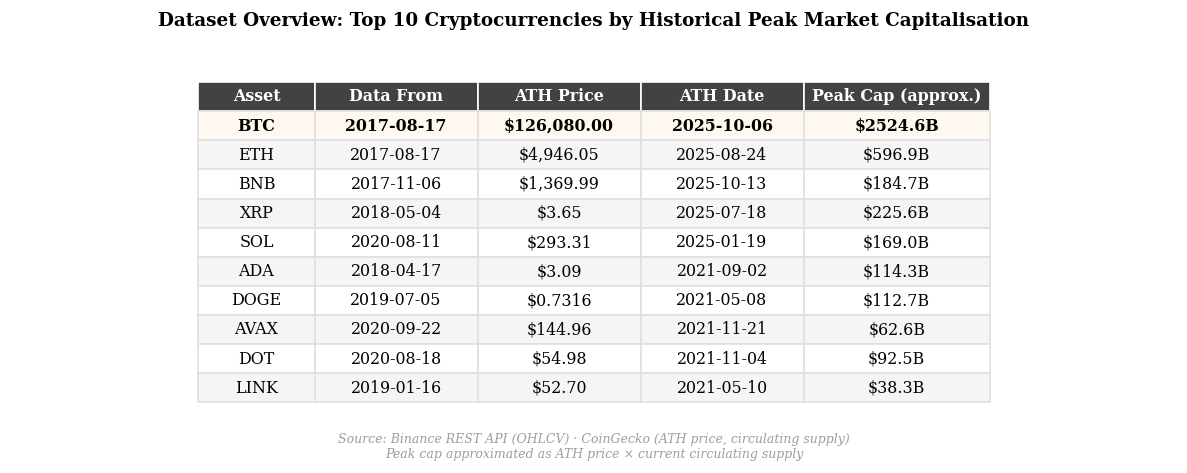

In [26]:
_df = caps_df.copy()
_df['Asset']     = _df['symbol'].str.replace('USDT', '')
_df['ATH Price'] = _df['ath_price_usd'].apply(lambda x: f'${x:,.2f}' if x >= 1 else f'${x:.4f}')
_df['ATH Date']  = _df['ath_date']
_df['Peak Cap']  = _df['peak_market_cap_usd'].apply(lambda x: f'${x/1e9:.1f}B')
_df['Data From'] = _df['earliest_1h_candle']

_td = _df[['Asset', 'Data From', 'ATH Price', 'ATH Date', 'Peak Cap']].values
_cl = ['Asset', 'Data From', 'ATH Price', 'ATH Date', 'Peak Cap (approx.)']

fig1, ax1 = plt.subplots(figsize=(10, 4.2))
ax1.axis('off')
tbl = ax1.table(cellText=_td, colLabels=_cl, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.6)

for j in range(len(_cl)):
    cell = tbl[0, j]
    cell.set_facecolor(DARKGREY)
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('white')

for i in range(1, len(_td) + 1):
    bg = '#FFF8F0' if i == 1 else ('#F5F5F5' if i % 2 == 0 else 'white')
    for j in range(len(_cl)):
        cell = tbl[i, j]
        cell.set_facecolor(bg)
        cell.set_edgecolor('#E0E0E0')
        if i == 1:
            cell.set_text_props(fontweight='bold')

for j, w in enumerate([0.10, 0.14, 0.14, 0.14, 0.16]):
    for i in range(len(_td) + 1):
        tbl[i, j].set_width(w)

fig1.suptitle(
    'Dataset Overview: Top 10 Cryptocurrencies by Historical Peak Market Capitalisation',
    fontsize=11, fontweight='bold', y=0.97,
)
ax1.text(
    0.5, -0.04,
    'Source: Binance REST API (OHLCV) · CoinGecko (ATH price, circulating supply)\n'
    'Peak cap approximated as ATH price × current circulating supply',
    ha='center', va='top', transform=ax1.transAxes,
    fontsize=7.5, color=GREY, style='italic',
)
fig1.tight_layout(rect=[0, 0.04, 1, 0.97])
fig1.savefig(FIGURES_DIR / 'fig1_market_cap_table.png')
plt.show()


## 2. Fetch OHLCV for all symbols

For each symbol, `fetch_and_store` fetches from its earliest available candle.
Re-running this cell is safe — only new rows since the last stored timestamp are downloaded (incremental update).

In [27]:
for symbol in COIN_IDS:
    row = caps_df[caps_df['symbol'] == symbol]
    if row.empty:
        print(f'  {symbol}: not found in caps_df — skipping')
        continue
    start_date = row.iloc[0]['earliest_1h_candle']
    print(f'Fetching {symbol} from {start_date}...')
    df = fetch_and_store(
        symbol=symbol,
        interval=INTERVAL,
        start=start_date,
        store_dir=str(RAW_DIR),
    )
    print(f'  {len(df):>7,} rows  {df.index.min().date()} → {df.index.max().date()}')


Fetching BTCUSDT from 2017-08-17...
   76,525 rows  2017-08-17 → 2026-05-16
Fetching ETHUSDT from 2017-08-17...
   76,525 rows  2017-08-17 → 2026-05-16
Fetching BNBUSDT from 2017-11-06...
   74,588 rows  2017-11-06 → 2026-05-16
Fetching XRPUSDT from 2018-05-04...
   70,321 rows  2018-05-04 → 2026-05-16
Fetching SOLUSDT from 2020-08-11...
   50,471 rows  2020-08-11 → 2026-05-16
Fetching ADAUSDT from 2018-04-17...
   70,733 rows  2018-04-17 → 2026-05-16
Fetching DOGEUSDT from 2019-07-05...
   60,113 rows  2019-07-05 → 2026-05-16
Fetching AVAXUSDT from 2020-09-22...
   49,463 rows  2020-09-22 → 2026-05-16
Fetching DOTUSDT from 2020-08-18...
   50,286 rows  2020-08-18 → 2026-05-16
Fetching LINKUSDT from 2019-01-16...
   64,179 rows  2019-01-16 → 2026-05-16


## 3. Sanity check — stored files

In [28]:
print(f'Files in {RAW_DIR}:\n')
for p in sorted(RAW_DIR.glob('*.parquet')):
    df_check = pd.read_parquet(p)
    print(f'  {p.name:<30} {len(df_check):>7,} rows  '
          f'{df_check.index.min().date()} → {df_check.index.max().date()}')


Files in /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/raw:

  ADAUSDT_1h.parquet              70,733 rows  2018-04-17 → 2026-05-16
  AVAXUSDT_1h.parquet             49,463 rows  2020-09-22 → 2026-05-16
  BNBUSDT_1h.parquet              74,588 rows  2017-11-06 → 2026-05-16
  BTCUSDT_1h.parquet              76,525 rows  2017-08-17 → 2026-05-16
  DOGEUSDT_1h.parquet             60,113 rows  2019-07-05 → 2026-05-16
  DOTUSDT_1h.parquet              50,286 rows  2020-08-18 → 2026-05-16
  ETHUSDT_1h.parquet              76,525 rows  2017-08-17 → 2026-05-16
  LINKUSDT_1h.parquet             64,179 rows  2019-01-16 → 2026-05-16
  SOLUSDT_1h.parquet              50,471 rows  2020-08-11 → 2026-05-16
  XRPUSDT_1h.parquet              70,321 rows  2018-05-04 → 2026-05-16
  btc_daily.parquet                2,316 rows  2020-01-01 → 2026-05-04


## 4. BTC daily chart

Load daily candles, compute indicators on the daily timeframe, and plot a research-grade chart with log-scale price, SMAs, Bollinger Bands and colour-coded volume bars.

In [29]:
# Resample hourly data to daily — no separate 1d fetch needed
btc_1h = load('BTCUSDT', '1h', store_dir=str(RAW_DIR))
btc_1h.index = btc_1h.index.tz_localize(None) if btc_1h.index.tz else btc_1h.index

btc_daily = btc_1h.resample('1D').agg({
    'open':   'first',
    'high':   'max',
    'low':    'min',
    'close':  'last',
    'volume': 'sum',
}).dropna()

# Indicators on daily candles
close = btc_daily['close']
btc_daily['SMA_50']   = close.rolling(50).mean()
btc_daily['SMA_200']  = close.rolling(200).mean()
_bb_mid               = close.rolling(20).mean()
_bb_std               = close.rolling(20).std()
btc_daily['BB_upper'] = _bb_mid + 2 * _bb_std
btc_daily['BB_lower'] = _bb_mid - 2 * _bb_std
btc_daily['vol_ma30'] = btc_daily['volume'].rolling(30).mean()

print(f'{len(btc_daily):,} daily rows  {btc_daily.index.min().date()} → {btc_daily.index.max().date()}')


3,195 daily rows  2017-08-17 → 2026-05-16


### Figure 2 — BTC/USDT daily price (log scale) with volume

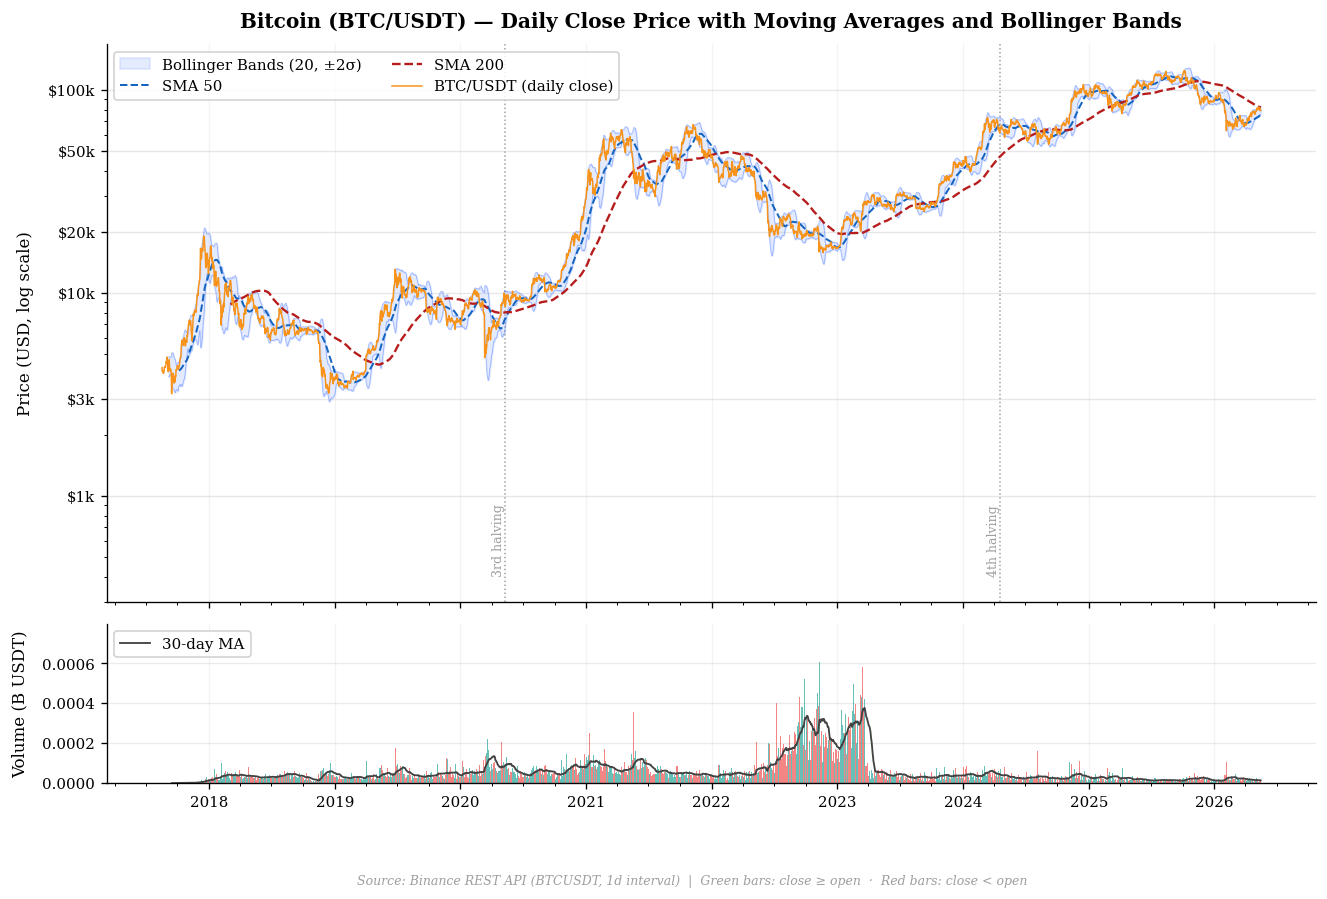

In [30]:
fig2, (ax_p, ax_v) = plt.subplots(
    2, 1, figsize=(13, 8),
    gridspec_kw={'height_ratios': [3.5, 1], 'hspace': 0.06},
    sharex=True,
)

# ── Price panel ───────────────────────────────────────────────────────────────
ax_p.fill_between(
    btc_daily.index, btc_daily['BB_lower'], btc_daily['BB_upper'],
    alpha=0.12, color=BLUE, label='Bollinger Bands (20, ±2σ)', zorder=1,
)
ax_p.plot(btc_daily.index, btc_daily['BB_upper'], lw=0.5, color=BLUE, alpha=0.35, zorder=2)
ax_p.plot(btc_daily.index, btc_daily['BB_lower'], lw=0.5, color=BLUE, alpha=0.35, zorder=2)
ax_p.plot(btc_daily.index, btc_daily['SMA_50'],   lw=1.2, color='#1565C0', ls='--', label='SMA 50',  zorder=3)
ax_p.plot(btc_daily.index, btc_daily['SMA_200'],  lw=1.4, color='#B71C1C', ls='--', label='SMA 200', zorder=3)
ax_p.plot(btc_daily.index, btc_daily['close'],    lw=0.9, color=ACCENT, label='BTC/USDT (daily close)', zorder=4)

ax_p.set_yscale('log')
ax_p.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}k' if x >= 1000 else f'${x:.0f}'
))
ax_p.yaxis.set_minor_formatter(mticker.NullFormatter())
ax_p.set_yticks([1000, 3000, 10000, 20000, 50000, 100000, 200000])
ax_p.set_ylim(300, btc_daily['close'].max() * 1.35)
ax_p.set_ylabel('Price (USD, log scale)', labelpad=8)
ax_p.legend(loc='upper left', ncol=2)
ax_p.set_title(
    'Bitcoin (BTC/USDT) — Daily Close Price with Moving Averages and Bollinger Bands',
    fontsize=12, fontweight='bold', pad=10,
)
ax_p.grid(axis='y', which='major', alpha=0.3)
ax_p.grid(axis='x', alpha=0.15)

# Halving annotations
for _date, _label in [('2020-05-11', '3rd halving'), ('2024-04-19', '4th halving')]:
    _x = pd.Timestamp(_date)
    if btc_daily.index.min() <= _x <= btc_daily.index.max():
        ax_p.axvline(_x, color=GREY, lw=0.9, ls=':', zorder=1)
        ax_p.text(_x, 400, _label, rotation=90, fontsize=7.5,
                  color=GREY, va='bottom', ha='right')

# ── Volume panel ─────────────────────────────────────────────────────────────
_colors = np.where(btc_daily['close'] >= btc_daily['open'], '#26A69A', '#EF5350')
ax_v.bar(btc_daily.index, btc_daily['volume'] / 1e9, width=1, color=_colors, alpha=0.7, zorder=2)
ax_v.plot(btc_daily.index, btc_daily['vol_ma30'] / 1e9, color=DARKGREY, lw=1.1,
          label='30-day MA', zorder=3)
ax_v.set_ylabel('Volume (B USDT)', labelpad=8)
ax_v.legend(loc='upper left')
ax_v.grid(axis='y', alpha=0.25)
ax_v.grid(axis='x', alpha=0.15)

ax_v.xaxis.set_major_locator(mdates.YearLocator())
ax_v.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_v.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

fig2.text(
    0.5, 0.005,
    'Source: Binance REST API (BTCUSDT, 1d interval)  |  '
    'Green bars: close ≥ open  ·  Red bars: close < open',
    ha='center', fontsize=7.5, color=GREY, style='italic',
)
fig2.savefig(FIGURES_DIR / 'fig2_btc_price_volume.png')
plt.show()


## 5. Feature engineering — extended BTCUSDT feature set

Loads `BTCUSDT_1h.parquet` from `data/raw/`, computes ~220 features across 13 groups,
and saves the result to `data/features/BTCUSDT_1h_features.parquet`.

A machine-readable feature registry is saved alongside as
`data/features/feature_registry.json` — this is the **single source of truth** for
all feature names, groups, and descriptions used by downstream notebooks and the
LightGBM pipeline.

No Binance API calls are made here.

In [31]:
from scipy.signal import argrelextrema

FEATURES_DIR = REPO_ROOT / 'data' / 'features'
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PARQUET = FEATURES_DIR / 'BTCUSDT_1h_features.parquet'
REGISTRY_PATH    = FEATURES_DIR / 'feature_registry.json'

# Load raw BTC 1h — reuse if already in memory from cell 4
if 'btc_1h' not in dir():
    btc_1h = load('BTCUSDT', '1h', store_dir=str(RAW_DIR))
    btc_1h.index = btc_1h.index.tz_localize(None) if btc_1h.index.tz else btc_1h.index

raw = btc_1h.copy()
print(f'Loaded {len(raw):,} rows  {raw.index.min().date()} → {raw.index.max().date()}')


Loaded 76,525 rows  2017-08-17 → 2026-05-16


In [32]:
# ── Helper functions shared across feature groups ─────────────────────────────

def candles_since(signal_arr):
    """Count candles since last True in a boolean/binary array."""
    count = np.zeros(len(signal_arr))
    c_ = 0
    for i, v in enumerate(signal_arr):
        c_ = 0 if v else c_ + 1
        count[i] = c_
    return count


def rsi(series, period):
    d    = series.diff()
    gain = d.clip(lower=0).ewm(alpha=1/period, adjust=False).mean()
    loss = (-d.clip(upper=0)).ewm(alpha=1/period, adjust=False).mean()
    return 100 - 100 / (1 + gain / (loss + 1e-12))


def supertrend(high, low, close, period=14, multiplier=2.0):
    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low  - close.shift(1)).abs(),
    ], axis=1).max(axis=1)
    atr  = tr.rolling(period).mean()
    hl2  = (high + low) / 2
    upper = hl2 + multiplier * atr
    lower = hl2 - multiplier * atr

    st_line = pd.Series(np.nan, index=close.index)
    st_dir  = pd.Series(np.nan, index=close.index)

    for i in range(1, len(close)):
        pu = upper.iloc[i-1]
        pl = lower.iloc[i-1]
        upper.iloc[i] = min(upper.iloc[i], pu) if close.iloc[i-1] > pu else upper.iloc[i]
        lower.iloc[i] = max(lower.iloc[i], pl) if close.iloc[i-1] < pl else lower.iloc[i]

        if close.iloc[i] > pu:
            st_dir.iloc[i] = 1.0
        elif close.iloc[i] < pl:
            st_dir.iloc[i] = -1.0
        else:
            st_dir.iloc[i] = st_dir.iloc[i-1]
        st_line.iloc[i] = lower.iloc[i] if st_dir.iloc[i] == 1.0 else upper.iloc[i]

    return st_line, st_dir


def fibonacci_features(high, low, close, lookback=168):
    swing_high = high.rolling(lookback).max()
    swing_low  = low.rolling(lookback).min()
    rng        = swing_high - swing_low + 1e-12
    fib_prices = {f: swing_low + f * rng for f in [0.0, 0.236, 0.382, 0.5, 0.618, 0.786, 1.0]}
    position     = (close - swing_low) / rng
    distances    = pd.DataFrame({f: (close - p).abs() / rng for f, p in fib_prices.items()})
    nearest_dist = distances.min(axis=1)
    valid_mask   = distances.notna().any(axis=1)
    nearest_lvl  = pd.Series(np.nan, index=distances.index)
    nearest_lvl[valid_mask] = distances[valid_mask].idxmin(axis=1).astype(float)
    dist_618     = (close - fib_prices[0.618]).abs() / rng
    below_618    = (close < fib_prices[0.618]).astype(float)
    return position, nearest_dist, nearest_lvl, dist_618, below_618


def mfi(high, low, close, volume, period=14):
    tp     = (high + low + close) / 3
    mf     = tp * volume
    pos_mf = mf.where(tp > tp.shift(1), 0)
    neg_mf = mf.where(tp < tp.shift(1), 0)
    mfr    = pos_mf.rolling(period).sum() / (neg_mf.rolling(period).sum() + 1e-12)
    return (100 - 100 / (1 + mfr)) / 100


def cmf(high, low, close, volume, period=20):
    clv = ((close - low) - (high - close)) / (high - low + 1e-12)
    return (clv * volume).rolling(period).sum() / (volume.rolling(period).sum() + 1e-12)


def vw_rsi(close, volume, period=14):
    delta = close.diff()
    gain  = (delta.clip(lower=0) * volume).rolling(period).mean()
    loss  = ((-delta.clip(upper=0)) * volume).rolling(period).mean()
    return (100 - 100 / (1 + gain / (loss + 1e-12))) / 100


def rolling_divergence(price, indicator, window=48, order=5):
    """Returns +1 bullish, -1 bearish, 0 none."""
    div     = pd.Series(0.0, index=price.index)
    pk_idx_arr = argrelextrema(price.values, np.greater, order=order)[0]
    tr_idx_arr = argrelextrema(price.values, np.less,    order=order)[0]
    peaks   = pd.Series(False, index=price.index)
    troughs = pd.Series(False, index=price.index)
    peaks.iloc[pk_idx_arr]   = True
    troughs.iloc[tr_idx_arr] = True

    for i in range(window, len(price)):
        sl = slice(i - window, i + 1)
        pk = np.where(peaks.iloc[sl])[0]
        tr = np.where(troughs.iloc[sl])[0]
        if len(pk) >= 2:
            p1, p2 = pk[-2], pk[-1]
            if (price.iloc[i - window + p2] > price.iloc[i - window + p1] and
                    indicator.iloc[i - window + p2] < indicator.iloc[i - window + p1]):
                div.iloc[i] = -1.0
        if len(tr) >= 2:
            t1, t2 = tr[-2], tr[-1]
            if (price.iloc[i - window + t2] < price.iloc[i - window + t1] and
                    indicator.iloc[i - window + t2] > indicator.iloc[i - window + t1]):
                div.iloc[i] = 1.0
    return div


def hurst_exponent(series, min_lag=2, max_lag=20):
    lags = range(min_lag, max_lag)
    tau  = [np.std(np.subtract(series[lag:], series[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0]


def rolling_hurst(returns, window=168):
    result = pd.Series(np.nan, index=returns.index)
    for i in range(window, len(returns)):
        try:
            result.iloc[i] = hurst_exponent(returns.iloc[i-window:i].values)
        except Exception:
            pass
    return result


def days_since_last_halving(index):
    HALVING_DATES = pd.to_datetime(['2012-11-28', '2016-07-09', '2020-05-11', '2024-04-20'])
    days = np.zeros(len(index))
    for i, ts in enumerate(index):
        past = HALVING_DATES[HALVING_DATES <= ts]
        days[i] = (ts - past[-1]).days if len(past) else 0
    return days


def streak_count(arr):
    result, count = np.zeros(len(arr)), 0
    for i, v in enumerate(arr):
        count = count + 1 if v else 0
        result[i] = count
    return result


def variance_ratio(returns, q):
    n   = len(returns)
    mu  = returns.mean()
    v1  = ((returns - mu)**2).sum() / (n - 1)
    vq  = ((returns.rolling(q).sum().dropna() - q*mu)**2).sum() / (n - q)
    return (vq / q) / (v1 + 1e-12)


print('Helper functions defined.')

Helper functions defined.


In [33]:
# ── Build extended feature set ────────────────────────────────────────────────
# Groups 1-12 from feature_engineering_expansion.md
# open column is preserved from raw data throughout and dropped at the end.

o = raw.copy()
c, h, l, v, op = o['close'], o['high'], o['low'], o['volume'], o['open']
log_ret1 = np.log(c / c.shift(1))

feature_registry = {}   # populated as we go: name -> {group, description}

def reg(names, group, desc_template):
    """Register a list of feature names."""
    for name in (names if isinstance(names, list) else [names]):
        feature_registry[name] = {'group': group, 'description': desc_template.format(name=name)}


# ── GROUP 0: Existing features (reference — already in 06_lgbm_agent) ─────────
for p in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
    o[f'ret_{p}h']     = c.pct_change(p)
    o[f'log_ret_{p}h'] = np.log(c / c.shift(p))
    reg([f'ret_{p}h', f'log_ret_{p}h'], 'returns', f'Return over {p}h window')

for w in [6, 12, 24, 48, 72, 168]:
    o[f'vol_{w}h'] = log_ret1.rolling(w).std()
    reg([f'vol_{w}h'], 'volatility', f'Rolling log-return std over {w}h')

tr = pd.concat([(h-l), (h-c.shift(1)).abs(), (l-c.shift(1)).abs()], axis=1).max(axis=1)
for w in [14, 24]:
    o[f'atr_{w}']     = tr.rolling(w).mean()
    o[f'atr_{w}_pct'] = o[f'atr_{w}'] / c
    reg([f'atr_{w}', f'atr_{w}_pct'], 'volatility', f'ATR {w}-period (raw and pct of close)')

o['sma_200'] = c.rolling(200).mean()   # kept for backtest, not ML feature

for w in [7, 14, 20, 50, 100, 200]:
    sma = c.rolling(w).mean()
    ema = c.ewm(span=w, adjust=False).mean()
    o[f'close_vs_sma_{w}'] = c / sma - 1
    o[f'close_vs_ema_{w}'] = c / ema - 1
    reg([f'close_vs_sma_{w}', f'close_vs_ema_{w}'], 'ma_ratios', f'Close vs SMA/EMA {w} (pct)')

for w in [20, 50]:
    mid = c.rolling(w).mean(); std = c.rolling(w).std()
    o[f'bb_width_{w}']    = (2*std) / (mid + 1e-12)
    o[f'bb_position_{w}'] = (c - (mid - 2*std)) / (4*std + 1e-12)
    reg([f'bb_width_{w}', f'bb_position_{w}'], 'bollinger', f'Bollinger Band width/position {w}')

for fast, slow, sig in [(12,26,9), (5,13,4)]:
    ef = c.ewm(span=fast, adjust=False).mean(); es = c.ewm(span=slow, adjust=False).mean()
    macd = ef - es; signal = macd.ewm(span=sig, adjust=False).mean()
    o[f'macd_{fast}_{slow}']      = macd / (c + 1e-12)
    o[f'macd_hist_{fast}_{slow}'] = (macd - signal) / (c + 1e-12)
    reg([f'macd_{fast}_{slow}', f'macd_hist_{fast}_{slow}'], 'macd', f'MACD ({fast},{slow}) normalized')

for p in [7, 14, 21]:
    o[f'rsi_{p}'] = rsi(c, p) / 100
    reg([f'rsi_{p}'], 'oscillators', f'RSI {p}-period (0-1 scaled)')

for w in [14, 21]:
    lo_w = l.rolling(w).min(); hi_w = h.rolling(w).max()
    o[f'stoch_k_{w}'] = (c - lo_w) / (hi_w - lo_w + 1e-12)
    reg([f'stoch_k_{w}'], 'oscillators', f'Stochastic %K {w}-period')
hi14 = h.rolling(14).max(); lo14 = l.rolling(14).min()
o['williams_r'] = (hi14 - c) / (hi14 - lo14 + 1e-12)
reg(['williams_r'], 'oscillators', 'Williams %R 14-period')

for w in [12, 24, 72, 168]:
    o[f'vol_z_{w}h']     = (v - v.rolling(w).mean()) / (v.rolling(w).std() + 1e-12)
    o[f'vol_ratio_{w}h'] = v / (v.rolling(w).mean() + 1e-12)
    reg([f'vol_z_{w}h', f'vol_ratio_{w}h'], 'volume', f'Volume z-score/ratio {w}h')
obv = (np.sign(log_ret1) * v).cumsum()
o['obv_z_72'] = (obv - obv.rolling(72).mean()) / (obv.rolling(72).std() + 1e-12)
reg(['obv_z_72'], 'volume', 'OBV z-score 72h')

o['candle_body'] = (c - op).abs() / (h - l + 1e-12)
o['upper_wick']  = (h - pd.concat([c, op], axis=1).max(axis=1)) / (h - l + 1e-12)
o['lower_wick']  = (pd.concat([c, op], axis=1).min(axis=1) - l) / (h - l + 1e-12)
o['is_bullish']  = (c > op).astype(float)
reg(['candle_body', 'upper_wick', 'lower_wick', 'is_bullish'], 'candle_structure', 'Candle body/wick structure')

for w in [24, 48, 168]:
    hi_w = h.rolling(w).max(); lo_w = l.rolling(w).min()
    o[f'hl_position_{w}h'] = (c - lo_w) / (hi_w - lo_w + 1e-12)
    reg([f'hl_position_{w}h'], 'price_position', f'High/low position {w}h')

o['hour_sin'] = np.sin(2*np.pi*o.index.hour/24)
o['hour_cos'] = np.cos(2*np.pi*o.index.hour/24)
o['dow_sin']  = np.sin(2*np.pi*o.index.dayofweek/7)
o['dow_cos']  = np.cos(2*np.pi*o.index.dayofweek/7)
reg(['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'], 'calendar', 'Hour/weekday sine-cosine encoding')


# ── GROUP 1: MA crosses ────────────────────────────────────────────────────────
sma20  = c.rolling(20).mean()
sma50  = c.rolling(50).mean()
sma100 = c.rolling(100).mean()
sma200 = c.rolling(200).mean()

o['sma50_vs_sma200']  = sma50  / (sma200 + 1e-12) - 1
o['sma20_vs_sma50']   = sma20  / (sma50  + 1e-12) - 1
o['sma50_vs_sma100']  = sma50  / (sma100 + 1e-12) - 1
o['sma100_vs_sma200'] = sma100 / (sma200 + 1e-12) - 1
o['golden_cross']     = (sma50 > sma200).astype(float)
cross_events          = (sma50 > sma200).astype(int).diff().abs()
o['candles_since_cross'] = candles_since(cross_events.values)
o['cross_recency']       = 1 / (o['candles_since_cross'] + 1)
o['ma_bull_score']       = (
    (sma20  > sma50 ).astype(int) +
    (sma50  > sma100).astype(int) +
    (sma100 > sma200).astype(int) +
    (c      > sma200).astype(int)
).astype(float)
ema7   = c.ewm(span=7,   adjust=False).mean()
ema200 = c.ewm(span=200, adjust=False).mean()
o['ma_ribbon_width'] = (ema7 - ema200).abs() / (c + 1e-12)

reg(['sma50_vs_sma200','sma20_vs_sma50','sma50_vs_sma100','sma100_vs_sma200'],
    'ma_crosses', 'Normalized SMA pair distance (golden/death cross)')
reg(['golden_cross','candles_since_cross','cross_recency','ma_bull_score','ma_ribbon_width'],
    'ma_crosses', 'MA cross signals: binary flag, recency, bull alignment score, ribbon width')


# ── GROUP 2: Ichimoku Cloud ────────────────────────────────────────────────────
tenkan = (h.rolling(9).max()  + l.rolling(9).min())  / 2
kijun  = (h.rolling(26).max() + l.rolling(26).min()) / 2
span_a = ((tenkan + kijun) / 2).shift(26)
span_b = ((h.rolling(52).max() + l.rolling(52).min()) / 2).shift(26)

o['tk_ratio']       = tenkan / (kijun + 1e-12) - 1
o['tk_cross_bull']  = ((tenkan > kijun) & (tenkan.shift(1) <= kijun.shift(1))).astype(float)
o['tk_cross_bear']  = ((tenkan < kijun) & (tenkan.shift(1) >= kijun.shift(1))).astype(float)

cloud_top    = pd.concat([span_a, span_b], axis=1).max(axis=1)
cloud_bottom = pd.concat([span_a, span_b], axis=1).min(axis=1)
o['close_vs_cloud_top']    = c / (cloud_top    + 1e-12) - 1
o['close_vs_cloud_bottom'] = c / (cloud_bottom + 1e-12) - 1
o['inside_cloud']          = ((c < cloud_top) & (c > cloud_bottom)).astype(float)
o['cloud_thickness']       = (span_a - span_b).abs() / (c + 1e-12)
o['cloud_bullish']         = (span_a > span_b).astype(float)
cloud_flip                 = (span_a > span_b).astype(int).diff().abs()
o['cloud_flip_recency']    = 1 / (candles_since(cloud_flip.fillna(0).values) + 1)
o['close_vs_kijun']        = c / (kijun + 1e-12) - 1

reg(['tk_ratio','tk_cross_bull','tk_cross_bear'], 'ichimoku', 'Ichimoku TK cross signals')
reg(['close_vs_cloud_top','close_vs_cloud_bottom','inside_cloud',
     'cloud_thickness','cloud_bullish','cloud_flip_recency','close_vs_kijun'],
    'ichimoku', 'Ichimoku cloud position and structure features')


# ── GROUP 3: SuperTrend ────────────────────────────────────────────────────────
for mult in [1.5, 2.0, 3.0]:
    st_level, st_dir = supertrend(h, l, c, period=14, multiplier=mult)
    label = str(mult).replace('.', '')
    o[f'supertrend_dir_{label}']  = st_dir
    o[f'supertrend_dist_{label}'] = (c - st_level) / (c + 1e-12)
    reg([f'supertrend_dir_{label}', f'supertrend_dist_{label}'],
        'supertrend', f'SuperTrend direction/distance (mult={mult})')

o['supertrend_consensus'] = (
    o['supertrend_dir_15'] + o['supertrend_dir_20'] + o['supertrend_dir_30']
) / 3
st_flip = (o['supertrend_dir_20'].diff().abs() > 0).astype(float)
o['supertrend_flip_recency'] = 1 / (candles_since(st_flip.values) + 1)
reg(['supertrend_consensus', 'supertrend_flip_recency'],
    'supertrend', 'SuperTrend consensus across multipliers + flip recency')


o = o.copy()  # defrag after SuperTrend inserts
c, h, l, v = o['close'], o['high'], o['low'], o['volume']

# ── GROUP 4: Fibonacci ────────────────────────────────────────────────────────
for lb in [48, 168]:
    pos, nd, nl, d618, b618 = fibonacci_features(h, l, c, lookback=lb)
    o[f'fib_position_{lb}h']      = pos
    o[f'fib_nearest_dist_{lb}h']  = nd
    o[f'fib_nearest_level_{lb}h'] = nl
    o[f'fib_dist_618_{lb}h']      = d618
    o[f'fib_below_618_{lb}h']     = b618
    reg([f'fib_position_{lb}h', f'fib_nearest_dist_{lb}h', f'fib_nearest_level_{lb}h',
         f'fib_dist_618_{lb}h', f'fib_below_618_{lb}h'],
        'fibonacci', f'Fibonacci retracement grid position (lookback={lb}h)')


# ── GROUP 5: Multi-timeframe / long-cycle MAs ─────────────────────────────────
for w in [336, 504, 720, 2160, 4320]:
    sma = c.rolling(w, min_periods=w//2).mean()
    ema = c.ewm(span=w, adjust=False).mean()
    o[f'close_vs_sma_{w}'] = c / (sma + 1e-12) - 1
    o[f'close_vs_ema_{w}'] = c / (ema + 1e-12) - 1
    reg([f'close_vs_sma_{w}', f'close_vs_ema_{w}'],
        'long_cycle_ma', f'Close vs SMA/EMA {w}h ({"2wk" if w==336 else "3wk" if w==504 else "1mo" if w==720 else "3mo" if w==2160 else "6mo"})')

ret_168 = c.pct_change(168)
o['weekly_mom_accel'] = ret_168 - ret_168.shift(168)
reg(['weekly_mom_accel'], 'long_cycle_ma', 'Weekly momentum acceleration (change in 168h return)')

HALVING_PERIOD_DAYS = 1458
days_since = days_since_last_halving(o.index)
cycle_phase = (days_since / HALVING_PERIOD_DAYS) * 2 * np.pi
o['halving_cycle_sin'] = np.sin(cycle_phase)
o['halving_cycle_cos'] = np.cos(cycle_phase)
o['halving_cycle_pos'] = days_since / HALVING_PERIOD_DAYS
reg(['halving_cycle_sin','halving_cycle_cos','halving_cycle_pos'],
    'calendar', 'BTC 4-year halving cycle encoding (sin/cos/linear position)')

o['dom_sin']     = np.sin(2*np.pi*o.index.day/31)
o['dom_cos']     = np.cos(2*np.pi*o.index.day/31)
o['quarter_sin'] = np.sin(2*np.pi*o.index.quarter/4)
o['quarter_cos'] = np.cos(2*np.pi*o.index.quarter/4)
reg(['dom_sin','dom_cos','quarter_sin','quarter_cos'],
    'calendar', 'Day-of-month and quarter sine-cosine encoding')


# ── GROUP 6: RSI / MACD / OBV divergences ────────────────────────────────────
print('Computing divergences (slow, ~60s)...')
rsi14     = rsi(c, 14)
macd_line = c.ewm(span=12, adjust=False).mean() - c.ewm(span=26, adjust=False).mean()

o['rsi_divergence']  = rolling_divergence(c, rsi14,    window=48, order=5)
o['macd_divergence'] = rolling_divergence(c, macd_line, window=48, order=5)
o['obv_divergence']  = rolling_divergence(c, obv,       window=48, order=5)
reg(['rsi_divergence','macd_divergence','obv_divergence'],
    'divergences', 'Price vs indicator divergence (+1 bullish, -1 bearish, 0 none)')

for w in [12, 24]:
    price_trend = c.pct_change(w)
    vol_trend   = v.pct_change(w)
    o[f'vol_price_div_{w}h'] = np.sign(price_trend) * (-np.sign(vol_trend))
    reg([f'vol_price_div_{w}h'], 'divergences', f'Volume-price divergence {w}h')


# ── GROUP 7: Candlestick patterns ─────────────────────────────────────────────
body     = c - op
body_abs = body.abs()
full_rng = h - l + 1e-12
body_pct = body_abs / full_rng

o['bull_engulf']   = ((body > 0) & (body.shift(1) < 0) & (c > op.shift(1)) & (op < c.shift(1))).astype(float)
o['bear_engulf']   = ((body < 0) & (body.shift(1) > 0) & (c < op.shift(1)) & (op > c.shift(1))).astype(float)
o['doji']          = (body_pct < 0.1).astype(float)
lower_wick2 = pd.concat([c, op], axis=1).min(axis=1) - l
upper_wick2 = h - pd.concat([c, op], axis=1).max(axis=1)
o['hammer']        = ((lower_wick2 > 2*body_abs) & (upper_wick2 < 0.3*full_rng) & (body_pct > 0.1)).astype(float)
o['shooting_star'] = ((upper_wick2 > 2*body_abs) & (lower_wick2 < 0.3*full_rng) & (body_pct > 0.1)).astype(float)
bull_streak_arr    = (c > op).astype(int).values
o['bull_streak']   = streak_count(bull_streak_arr)
o['bear_streak']   = streak_count((~(c > op)).astype(int).values)
o['marubozu']      = (body_pct > 0.85).astype(float)
reg(['bull_engulf','bear_engulf','doji','hammer','shooting_star','bull_streak','bear_streak','marubozu'],
    'candlestick_patterns', 'Multi-bar reversal/continuation pattern encoding')


# ── GROUP 8: Volume profile & order flow ─────────────────────────────────────
typical = (h + l + c) / 3
for w in [24, 168]:
    vwap = (typical * v).rolling(w).sum() / (v.rolling(w).sum() + 1e-12)
    o[f'close_vs_vwap_{w}h'] = c / (vwap + 1e-12) - 1
    reg([f'close_vs_vwap_{w}h'], 'volume_profile', f'Close vs VWAP {w}h')

o['mfi_14']  = mfi(h, l, c, v, 14)
o['mfi_21']  = mfi(h, l, c, v, 21)
o['cmf_20']  = cmf(h, l, c, v, 20)
reg(['mfi_14','mfi_21','cmf_20'], 'volume_profile', 'Money Flow Index (14,21) and Chaikin MF (20)')

clv = ((c - l) - (h - c)) / (h - l + 1e-12)
ad  = (clv * v).cumsum()
for w in [48, 168]:
    o[f'ad_z_{w}h'] = (ad - ad.rolling(w).mean()) / (ad.rolling(w).std() + 1e-12)
    reg([f'ad_z_{w}h'], 'volume_profile', f'Accumulation/Distribution z-score {w}h')

for mult in [2.0, 3.0]:
    label = str(int(mult))
    o[f'vol_spike_{label}x'] = (v > mult * v.rolling(24).mean()).astype(float)
    reg([f'vol_spike_{label}x'], 'volume_profile', f'Volume spike flag (>{int(mult)}× 24h mean)')

o['vw_rsi_14'] = vw_rsi(c, v, 14)
reg(['vw_rsi_14'], 'volume_profile', 'Volume-weighted RSI 14-period')


# ── GROUP 9: Support, resistance & pivot points ────────────────────────────────
prev_h = h.shift(24).rolling(24).max()
prev_l = l.shift(24).rolling(24).min()
prev_c = c.shift(24)
pivot  = (prev_h + prev_l + prev_c) / 3
r1 = 2*pivot - prev_l;  s1 = 2*pivot - prev_h
r2 = pivot + (prev_h - prev_l); s2 = pivot - (prev_h - prev_l)
o['close_vs_pivot'] = (c - pivot) / (c + 1e-12)
o['close_vs_r1']    = (c - r1)    / (c + 1e-12)
o['close_vs_s1']    = (c - s1)    / (c + 1e-12)
o['close_vs_r2']    = (c - r2)    / (c + 1e-12)
o['close_vs_s2']    = (c - s2)    / (c + 1e-12)
reg(['close_vs_pivot','close_vs_r1','close_vs_s1','close_vs_r2','close_vs_s2'],
    'support_resistance', 'Classic daily pivot points (P, R1/R2, S1/S2)')

o['dist_round_1000']  = (c - (c/1000).round()*1000).abs() / c
o['dist_round_10000'] = (c - (c/10000).round()*10000).abs() / c
reg(['dist_round_1000','dist_round_10000'], 'support_resistance', 'Distance to round BTC price levels')

for w in [24, 48, 168]:
    ph = h.shift(1).rolling(w).max(); pl = l.shift(1).rolling(w).min()
    rng_w = ph - pl + 1e-12
    o[f'breakout_up_{w}h']   = ((c - ph) / rng_w).clip(lower=0)
    o[f'breakout_down_{w}h'] = ((pl - c) / rng_w).clip(lower=0)
    reg([f'breakout_up_{w}h', f'breakout_down_{w}h'],
        'support_resistance', f'Breakout magnitude above/below {w}h range')


# ── GROUP 10: Volatility regime ────────────────────────────────────────────────
log_hl = np.log(h / (l + 1e-12))
log_co = np.log(c / (op + 1e-12))
gk_var = 0.5 * log_hl**2 - (2*np.log(2) - 1) * log_co**2
for w in [24, 72, 168]:
    o[f'gk_vol_{w}h'] = gk_var.rolling(w).mean().apply(np.sqrt)
    reg([f'gk_vol_{w}h'], 'volatility_regime', f'Garman-Klass volatility {w}h')

park_var = (np.log(h / (l + 1e-12))**2) / (4 * np.log(2))
for w in [24, 72]:
    o[f'park_vol_{w}h'] = park_var.rolling(w).mean().apply(np.sqrt)
    reg([f'park_vol_{w}h'], 'volatility_regime', f'Parkinson volatility {w}h')

vol24 = log_ret1.rolling(24).std()
o['vol_of_vol_72h'] = vol24.rolling(72).std() / (vol24.rolling(72).mean() + 1e-12)
reg(['vol_of_vol_72h'], 'volatility_regime', 'Volatility of volatility (72h)')

for w in [14, 24]:
    atr_col = o[f'atr_{w}_pct']
    o[f'atr_{w}_pct_rank'] = atr_col.rolling(720).rank(pct=True)
    reg([f'atr_{w}_pct_rank'], 'volatility_regime', f'ATR {w} percentile rank vs 720h history')

for w in [20, 50]:
    bb_w = o[f'bb_width_{w}']
    o[f'bb_squeeze_{w}'] = bb_w.rolling(168).rank(pct=True)
    reg([f'bb_squeeze_{w}'], 'volatility_regime', f'BB squeeze percentile rank (168h) for band {w}')

o['range_vs_atr'] = (h - l) / (o['atr_14'] + 1e-12)
reg(['range_vs_atr'], 'volatility_regime', 'Current range vs ATR14 (< 0.5 = inside bar / compression)')


# ── GROUP 11: Statistical / regime features ────────────────────────────────────
print('Computing Hurst (slow, ~2min)...')
o['hurst_168h'] = rolling_hurst(log_ret1, window=168)
reg(['hurst_168h'], 'statistical', 'Rolling Hurst exponent 168h (>0.5 trending, <0.5 mean-reverting)')

for w in [24, 72, 168]:
    o[f'skew_{w}h'] = log_ret1.rolling(w).skew()
    o[f'kurt_{w}h'] = log_ret1.rolling(w).kurt()
    reg([f'skew_{w}h', f'kurt_{w}h'], 'statistical', f'Return skewness/kurtosis {w}h')

for lag in [1, 6, 12, 24]:
    o[f'autocorr_ret_{lag}h'] = log_ret1.rolling(72).apply(
        lambda x: x.autocorr(lag=lag) if len(x) > lag else np.nan, raw=False
    )
    reg([f'autocorr_ret_{lag}h'], 'statistical', f'Rolling autocorrelation of returns lag={lag}h (72h window)')

for q in [6, 24]:   # skip 168 — too slow without Numba
    o[f'var_ratio_{q}h'] = log_ret1.rolling(336).apply(
        lambda x: variance_ratio(x, q) if len(x) >= q*2 else np.nan, raw=False
    )
    reg([f'var_ratio_{q}h'], 'statistical', f'Variance ratio test q={q}h (Lo-MacKinlay, 336h window)')


# ── GROUP 12: Composite / interaction features ────────────────────────────────
o['trend_score'] = (
    (o['macd_12_26'] > 0).astype(int) +
    (o['rsi_14']     > 0.5).astype(int) +
    (o['close_vs_sma_50']  > 0).astype(int) +
    (o['close_vs_sma_200'] > 0).astype(int) +
    (o['golden_cross']).astype(int)
).astype(float)
reg(['trend_score'], 'composite', 'Trend alignment score (0-5 bullish signals)')

o['rsi_vol_confirm'] = o['rsi_14'] * o['vol_ratio_24h'].clip(0, 5) / 5
reg(['rsi_vol_confirm'], 'composite', 'RSI × volume confirmation (conviction-weighted RSI)')

o['mom_coherence'] = np.sign(o['ret_6h']) * np.sign(o['ret_168h'])
reg(['mom_coherence'], 'composite', 'Short/long momentum coherence (+1 aligned, -1 diverging)')

for p in [24, 72, 168]:
    o[f'sharpe_ratio_{p}h'] = o[f'ret_{p}h'] / (o[f'vol_{p}h'] + 1e-12)
    reg([f'sharpe_ratio_{p}h'], 'composite', f'Realized Sharpe ratio {p}h')

if 'hurst_168h' in o.columns:
    o['regime_composite'] = (
        o['hurst_168h'].clip(0, 1) +
        o['bb_squeeze_20'] +
        o['atr_14_pct_rank']
    ) / 3
    reg(['regime_composite'], 'composite', 'Regime composite: Hurst + BB squeeze + ATR rank (0-1)')


# ── Label ─────────────────────────────────────────────────────────────────────
o['label'] = (c.shift(-1) > c).astype(int)

# ── Clean up ─────────────────────────────────────────────────────────────────
BACKTEST_COLS = ['close', 'sma_200', 'atr_14_pct']
drop_raw      = ['open', 'high', 'low', 'volume']
o = o.drop(columns=[col for col in drop_raw if col in o.columns])
o = o.replace([np.inf, -np.inf], np.nan)

all_feature_cols = [c for c in o.columns if c not in BACKTEST_COLS + ['label']]
print(f'\nTotal features before dropna: {len(all_feature_cols)}')
print(f'Rows before dropna:           {len(o):,}')
o_clean = o.dropna()
print(f'Rows after dropna:            {len(o_clean):,}')

/var/folders/_6/2m0ng9zx49z80p26ckg19sdr0000gp/T/ipykernel_89509/2282924937.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  o[f'supertrend_dist_{label}'] = (c - st_level) / (c + 1e-12)
/var/folders/_6/2m0ng9zx49z80p26ckg19sdr0000gp/T/ipykernel_89509/2282924937.py:159: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  o['supertrend_consensus'] = (
/var/folders/_6/2m0ng9zx49z80p26ckg19sdr0000gp/T/ipykernel_89509/2282924937.py:163: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.i

Computing divergences (slow, ~60s)...
Computing Hurst (slow, ~2min)...

Total features before dropna: 195
Rows before dropna:           76,525
Rows after dropna:            74,366


In [34]:
# ── Save feature parquet ──────────────────────────────────────────────────────
o_clean.to_parquet(FEATURES_PARQUET)
print(f'Saved → {FEATURES_PARQUET}')
print(f'Shape: {o_clean.shape}  ({len(all_feature_cols)} features + {len(BACKTEST_COLS)} backtest cols + label)')
print(f'Date range: {o_clean.index.min().date()} → {o_clean.index.max().date()}')


Saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/features/BTCUSDT_1h_features.parquet
Shape: (74366, 199)  (195 features + 3 backtest cols + label)
Date range: 2017-11-15 → 2026-05-16


In [35]:
# ── Save feature registry (single source of truth) ────────────────────────────
# Groups summary
groups = {}
for fname, meta in feature_registry.items():
    g = meta['group']
    groups.setdefault(g, []).append(fname)

registry_output = {
    'generated_at':  pd.Timestamp.now().isoformat(),
    'source_data':   'BTCUSDT_1h.parquet',
    'output_parquet':'BTCUSDT_1h_features.parquet',
    'total_features': len(feature_registry),
    'backtest_only_cols': BACKTEST_COLS,
    'label_col': 'label',
    'groups': {g: {'count': len(names), 'features': names} for g, names in sorted(groups.items())},
    'features': feature_registry,
}

import json
with open(REGISTRY_PATH, 'w') as f:
    json.dump(registry_output, f, indent=2)

print(f'Saved → {REGISTRY_PATH}')
print(f'\nFeature groups:')
for g, names in sorted(groups.items()):
    print(f'  {g:<25} {len(names):>3} features')
print(f'  {"-"*35}')
print(f'  {"TOTAL":<25} {len(feature_registry):>3} features')


Saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/features/feature_registry.json

Feature groups:
  bollinger                   4 features
  calendar                   11 features
  candle_structure            4 features
  candlestick_patterns        8 features
  composite                   7 features
  divergences                 5 features
  fibonacci                  10 features
  ichimoku                   10 features
  long_cycle_ma              11 features
  ma_crosses                  9 features
  ma_ratios                  12 features
  macd                        4 features
  oscillators                 6 features
  price_position              3 features
  returns                    18 features
  statistical                13 features
  supertrend                  8 features
  support_resistance         13 features
  volatility                 10 features
  volatility_regime          11 features
  volume                      9 features
  volume_pr

In [36]:
# ── Quick sanity check ────────────────────────────────────────────────────────
df_check = pd.read_parquet(FEATURES_PARQUET)
print('Parquet loaded OK')
print(f'Shape: {df_check.shape}')
print(f'NaN count: {df_check.isna().sum().sum()}')
print(f'\nSample features:')
print(df_check[all_feature_cols[:10]].describe().T[['mean','std','min','max']].round(4).to_string())


Parquet loaded OK
Shape: (74366, 199)
NaN count: 0

Sample features:
               mean     std     min     max
ret_1h       0.0001  0.0075 -0.1821  0.1738
log_ret_1h   0.0000  0.0076 -0.2010  0.1603
ret_2h       0.0001  0.0105 -0.1978  0.2510
log_ret_2h   0.0001  0.0105 -0.2204  0.2239
ret_3h       0.0002  0.0126 -0.2882  0.1833
log_ret_3h   0.0001  0.0127 -0.3399  0.1683
ret_6h       0.0004  0.0175 -0.3158  0.3039
log_ret_6h   0.0002  0.0176 -0.3795  0.2653
ret_12h      0.0007  0.0244 -0.3109  0.3577
log_ret_12h  0.0004  0.0245 -0.3723  0.3058
